# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [12]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

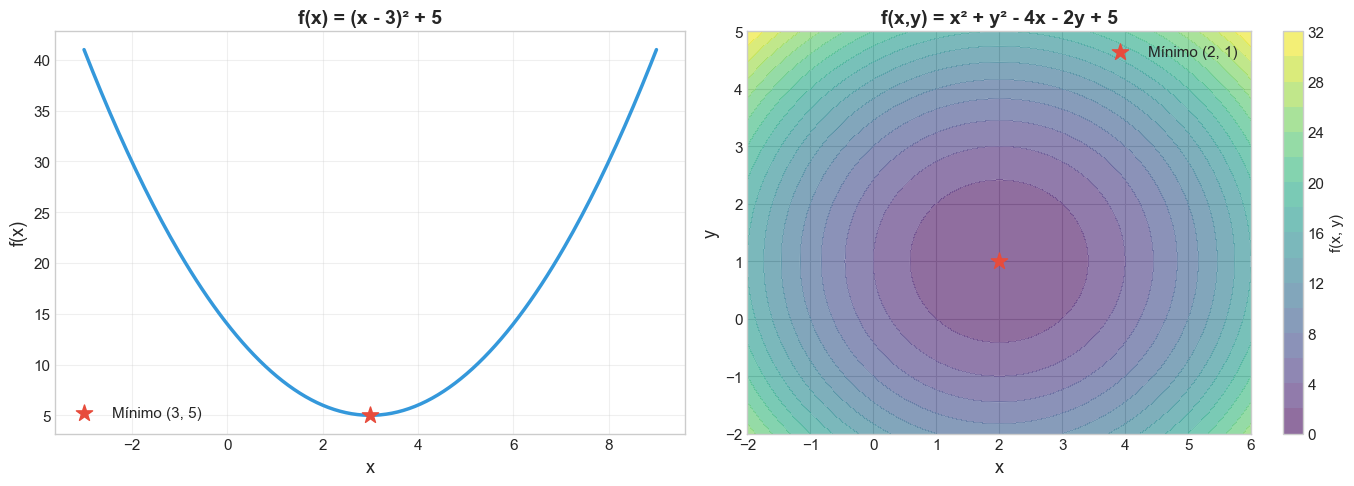

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [2]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [7]:
def f_1d(x):
    return (x - 3)**2 + 5


def df_1d(x):
    return 2 * (x - 3)    

def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa las variables:
    #    - x_actual = x_inicial
    #    - historial_x = [x_inicial]
    #    - historial_f = [f_1d(x_inicial)]
    #    - convergido = False
    
    # 2. Loop principal (max_iter iteraciones):
    #    a. Calcula el gradiente: g = df_1d(x_actual)
    #    b. Actualiza: x_nuevo = x_actual - learning_rate * g
    #    c. Guarda en historial
    #    d. Verifica convergencia: si |x_nuevo - x_actual| < tolerancia -> convergido
    #    e. Actualiza x_actual = x_nuevo
    
    # 3. Retorna el diccionario con resultados
    
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_actual)]
    convergido = False
    
    for i in range(max_iter):
        g = df_1d(x_actual)
        x_nuevo = x_actual - learning_rate * g
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break
        
        x_actual = x_nuevo
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': i + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [4]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


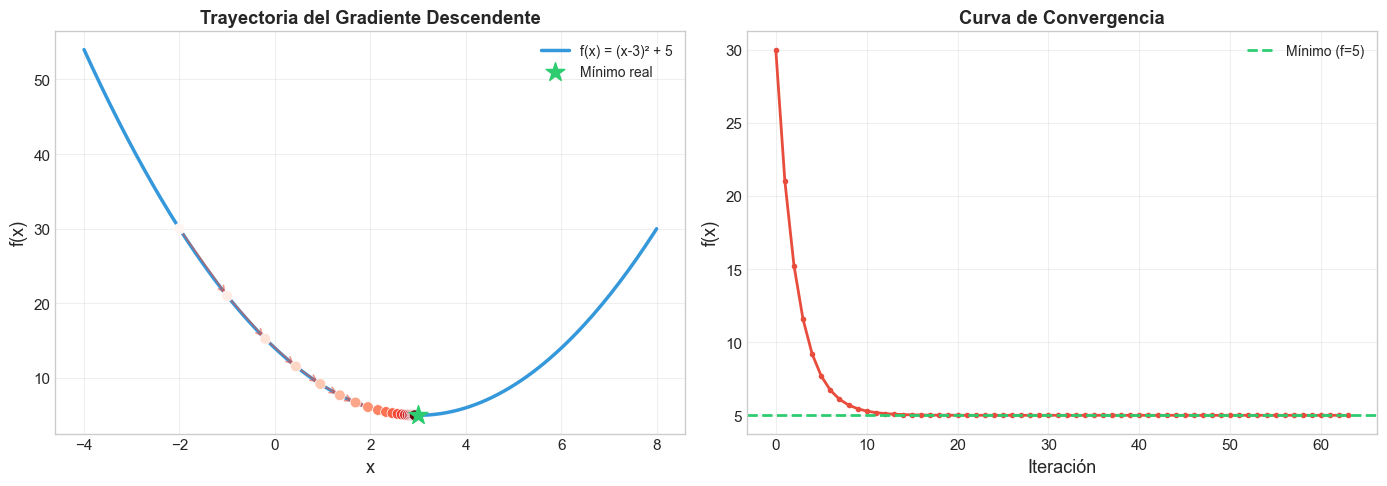

In [5]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [11]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200
   
# Almacenar resultados
resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr
for lr in learning_rates_prueba:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba,
        learning_rate=lr,
        max_iter=max_iter_prueba
    )
    resultados_lr.append(res)


# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':<8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergio':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
LR            x_final   f(x)_final  Iteraciones    Convergio
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

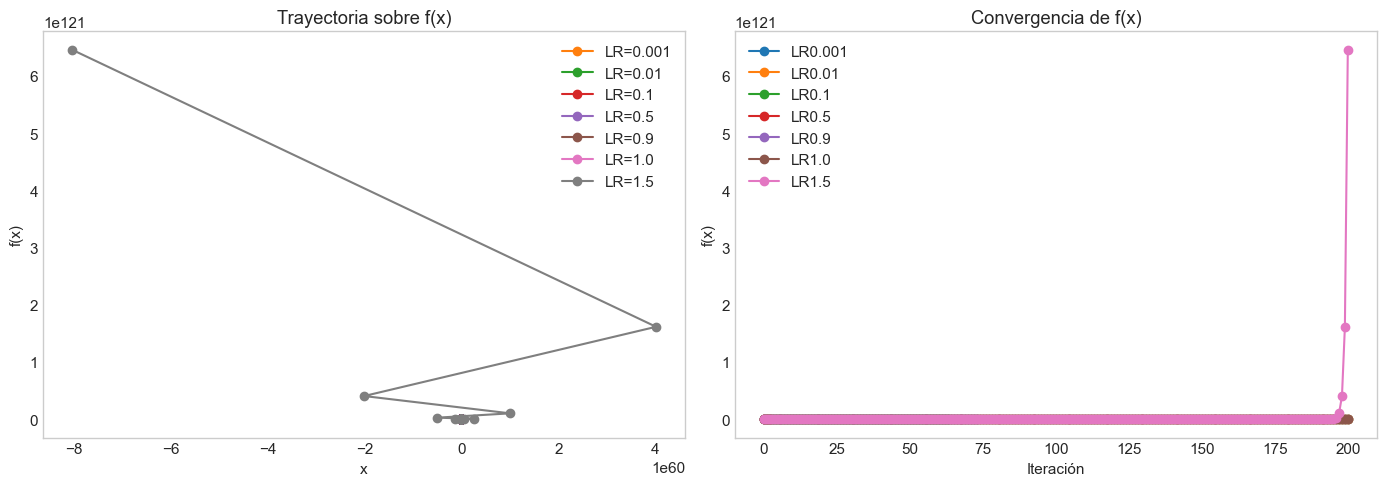

In [13]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

# Crea dos graficas:
# 1. Trayectoria sobre f(x) para cada LR (con diferentes colores)
# 2. Curva de convergencia f(x) vs iteracion para cada LR

# Pista: usa fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pista: usa colores distintos para cada LR

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_vals = np.linspace(-5, 10, 200)
y_vals = (x_vals - 3)**2 + 5

axes[0].plot(x_vals, y_vals, linestyle='--')
for lr, res in zip(learning_rates_prueba, resultados_lr):
    x_hist = res['historial_x']
    f_hist = res['historial_f']
    
    axes[0].plot(x_hist, f_hist, marker='o', label=f'LR={lr}')

axes[0].set_title("Trayectoria sobre f(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].legend()
axes[0].grid()

for lr, res in zip(learning_rates_prueba, resultados_lr):
    f_hist = res['historial_f']
    
    axes[1].plot(f_hist, marker='o', label=f'LR{lr}')
    
axes[1].set_title("Convergencia de f(x)")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("f(x)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

**Responde estas preguntas basandote en tus experimentos:**

1. **¿Qué pasa con un learning rate muy pequeño (0.001)?**
   - *Pues provocaria que convergiera de una forma muy lenta, ya que los pasos que da el gradiente descendiente son muy pequeños, por lo que es necesario que tenmga muchas iteraciones para acercarse al minimo.*

2. **¿Cuál consideras el mejor learning rate y por que?**
   - *Yo consideraria un buen learning rate aproximadamente de 0.1, ya que este valor logra un equilibrio entre velocidad y estabilidad.*

3. **¿Qué pasa con learning rates >= 1.0?**
   - *Caundo el learning rate es mayor o igual a 1.0, pues puede que el algoritmo se vuelva inestable, ya que en vez de acercarse al minimo, los valores empiezan a oscilar o incluso a divergir.*

4. **¿Por qué un learning rate de exactamente 1.0 tiene un comportamiento especial para esta función?**
   - *Pues como provoca un comportamiento oscilatorio y como en esta funcion, el gradiente es proporcional a 2(x - 3), por lo que hacer que el valor de x salte de un lado al otro del minimo son converger.*

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [14]:
def f_2d(x, y):
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    return np.array([2*x - 4, 2*y - 2])

def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa:
    #    - x_actual, y_actual = x_inicial, y_inicial
    #    - historiales vacios
    
    # 2. Loop principal:
    #    a. Calcula gradiente: g = grad_2d(x_actual, y_actual)  -> [gx, gy]
    #    b. Actualiza ambos parametros:
    #       x_nuevo = x_actual - lr * g[0]
    #       y_nuevo = y_actual - lr * g[1]
    #    c. Guarda en historiales
    #    d. Verifica convergencia: si ||gradiente|| < tolerancia -> convergido
    #       (norma del gradiente: np.linalg.norm(g))
    #    e. Actualiza x_actual, y_actual
    
    # 3. Retorna diccionario con resultados
    
    x_actual, y_actual = x_inicial, y_inicial
    historial_x = [x_actual]
    historial_y = [y_actual]
    historial_f = [f_2d(x_actual, y_actual)]
    convergido = False
    
    for i in range(max_iter):
        g = grad_2d(x_actual, y_actual)
        
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            x_actual, y_actual = x_nuevo, y_nuevo
            break
        x_actual, y_actual = x_nuevo, y_nuevo
        
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': i + 1,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }

### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [15]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


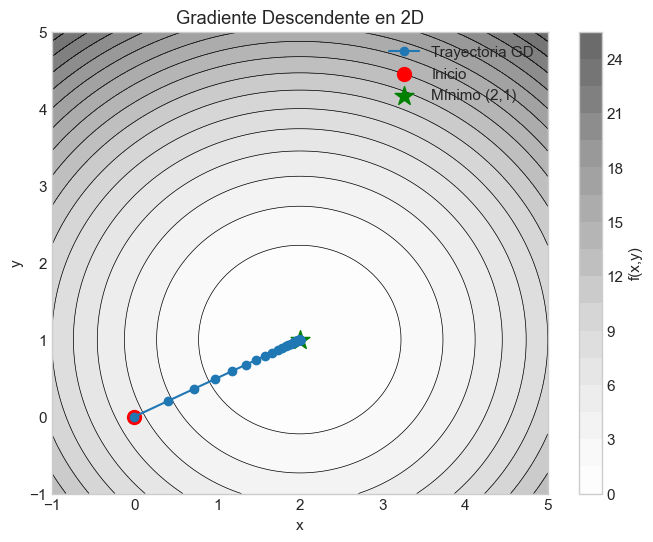

In [17]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria

x = np.linspace(-1, 5, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2 - 4*X - 2*Y + 5

res = gradiente_descendente_2d(
    x_inicial=0,
    y_inicial=0,
    learning_rate=0.1
)

hist_x = res['historial_x']
hist_y = res['historial_y']

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=20, alpha=0.6)
plt.colorbar(label="f(x,y)")
plt.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)
plt.plot(hist_x, hist_y, 'o-', label='Trayectoria GD')
plt.scatter(hist_x[0], hist_y[0], color='red', s=100, label='Inicio')
plt.scatter(2, 1, color='green', marker='*', s=200, label='Mínimo (2,1)')
plt.title("Gradiente Descendente en 2D")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

In [18]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

learning_rate = 0.1
max_iter = 200
resultados = []

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados

for x0, y0 in puntos_iniciales:
    res = gradiente_descendente_2d(
        x_inicial=x0,
        y_inicial=y0,
        learning_rate=learning_rate,
        max_iter=max_iter
    )
    
    resultados.append(res)
    
print("Resultados con diferentes puntos iniciales")
print(f"{'Inicio (x,y)':<20} {'x_final':>10} {'y_final':>10} {'f_final':>10} {'Iter':>8} {'Conv':>8}")
for (x0, y0), res in zip(puntos_iniciales, resultados):
    print(f"{str((x0,y0)):<20} {res['x_final']:>10.4f} {res['y_final']:>10.4f} {res['f_final']:>10.4f} {res['iteraciones']:>8} {str(res['convergido']):>8}")


Resultados con diferentes puntos iniciales
Inicio (x,y)            x_final    y_final    f_final     Iter     Conv
(-1.0, 4.0)              2.0000     1.0000     0.0000       73     True
(5.0, -1.0)              2.0000     1.0000     0.0000       72     True
(0.0, 0.0)               2.0000     1.0000     0.0000       70     True


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [20]:
# ============================================================
# TU CODIGO AQUI: Genera el DataFrame con todos los experimentos
# ============================================================

# 1. Ejecuta TODOS los experimentos:
#    - 1D: learning_rates [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
#           desde x=-2.0
#    - 2D: learning_rates [0.001, 0.01, 0.1, 0.5]
#           desde (-1, 4), (5, -1), (0, 0)

# 2. Crea el DataFrame

# 3. Guardalo como CSV

# df_experimentos = pd.DataFrame(...)
# df_experimentos.to_csv('experimentos_gd.csv', index=False)

registros = []
learning_rate_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_1d = -2.0

for lr in learning_rate_1d:
    res = gradiente_descendente_1d(
        x_inicial=x_inicial_1d,
        learning_rate=lr,
        max_iter=200
    )
    registros.append({
        'learning_rate': lr,
        'dimension': '1D',
        'x_inicial': x_inicial_1d,
        'y_inicial': np.nan,
        'x_final': res['x_final'],
        'y_final': np.nan,
        'valor_minimo': res['f_final'],
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido']
    })
learning_rates_2d = [0.001, 0.01, 0.1, 0.5]
puntos_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for lr in learning_rates_2d:
    for x0, y0 in puntos_2d:
        
        res = gradiente_descendente_2d(
            x_inicial=x0,
            y_inicial=y0,
            learning_rate=lr,
            max_iter=200
        )
        
        registros.append({
            'learning_rate': lr,
            'dimension': '2D',
            'x_inicial': x0,
            'y_inicial': y0,
            'x_final': res['x_final'],
            'y_final': res['y_final'],
            'valor_minimo': res['f_final'],
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido']
        })
df_experimentos = pd.DataFrame(registros)
df_experimentos.to_csv('experimentos_GD.csv', index=False)




In [21]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

# df_experimentos = pd.read_csv('experimentos_gd.csv')
# print(df_experimentos.to_string(index=False))
# print(f"\nTotal de experimentos: {len(df_experimentos)}")
print("CSV de Experimentos")
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")

CONTENIDO DEL CSV DE EXPERIMENTOS
CSV de Experimentos
 learning_rate dimension  x_inicial  y_inicial       x_final   y_final  valor_minimo  iteraciones  convergido
         0.001        1D       -2.0        NaN -3.502581e-01       NaN  1.622423e+01          200       False
         0.010        1D       -2.0        NaN  2.912060e+00       NaN  5.007733e+00          200       False
         0.100        1D       -2.0        NaN  2.999996e+00       NaN  5.000000e+00           63        True
         0.500        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00            2        True
         0.900        1D       -2.0        NaN  3.000000e+00       NaN  5.000000e+00           73        True
         1.000        1D       -2.0        NaN -2.000000e+00       NaN  3.000000e+01          200       False
         1.500        1D       -2.0        NaN -8.034690e+60       NaN 6.455625e+121          200       False
         0.001        2D       -1.0        4.0 -1.015484e-02  3.01

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **¿Cuál es el rango de learning rates que funciona bien para estas funciones?**
   - *El learning rates que funciona bien yo diria que es el 0.01 y 0.5, ya que en este intervalo el algoritmo converge de manera estable y relativamente rapido, y los valores muy pequeños hacer que la convergencia sea mas lenta, mientras que los valores cercanos o mayores a 1 provocan la inestabilidad o divergencia en el modelo*

2. **El punto inicial afecta si el algoritmo converge? Afecta cuántas iteraciones necesita?**
   - *El punto inicial no afecta si el algoritmo ya convergio, ya que la funcion es convexa y tiene un unico minimo local.*

3. **¿Qué pasaría si la función tuviera minimos locales?**
   - *El algoritmo podria converger a diferentes soluciones dependiendo del punto inicial, y eso se refiere a que no nada mas encontraria un minimo global, sino el minimo local mas cercano*

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la función de costo es como `f(x,y)`. Por qué es importante elegir bien el learning rate al entrenar?**
   - *En ML los parametros del modelo se optimizan de forma muy parecida a como se ajustan x e y en el gradiente descendiente y la funcion de costo representa que tan bien se ajusta el modelo con los datos.*

5. **¿Qué ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Principalmente tiene una busqueda dirigida hacia el minimo, aprovechando la pendiente de la funcion y esto hace que el proceso sea mucho mas eficiente y rapido en comparacion con probar valores al azar, ya que cada paso tiene una direccion optima de mejora.*

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [22]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [23]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa w = 0, b = 0
    # 2. Para cada epoch:
    #    a. Mezcla los indices aleatoriamente
    #    b. Para cada mini-batch:
    #       - Selecciona batch_size muestras
    #       - Calcula prediccion: y_pred = w * X_batch + b
    #       - Calcula error: error = y_batch - y_pred
    #       - Calcula gradientes:
    #           dw = -2/batch_size * sum(error * X_batch)
    #           db = -2/batch_size * sum(error)
    #       - Actualiza: w = w - lr * dw, b = b - lr * db
    #    c. Calcula MSE del epoch completo y guarda en historial
    
    n = len(x)
    w = 0.0
    b = 0.0
    
    historial_loss = []
    historial_w = []
    historial_b = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            y_pred = w * X_batch + b
            error = y_batch - y_pred
            
            dw = -2/len(X_batch) * np.sum(error * X_batch)
            db = -2/len(X_batch) * np.sum(error)
            
            w = w - learning_rate * dw
            b = b - learning_rate * db
        y_pred_total = w * X + b
        loss = np.mean((y - y_pred_total)**2)
        
        historial_loss.append(loss)
        historial_w.append(w)
        historial_b.append(b)
    return{
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }

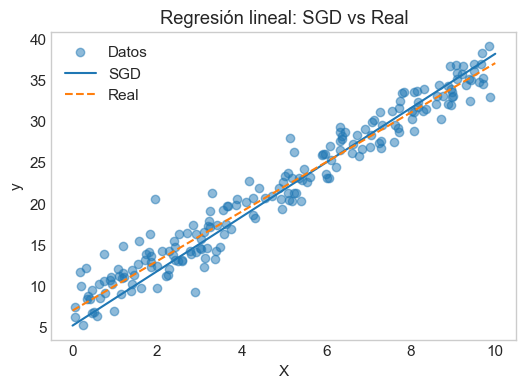

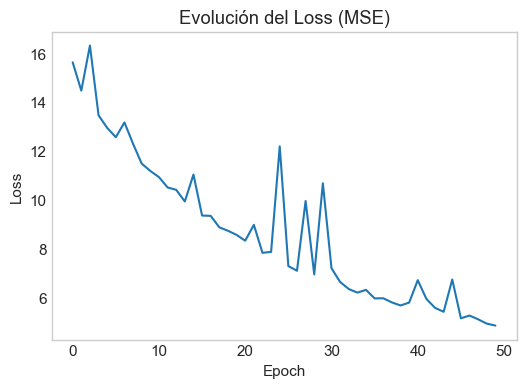

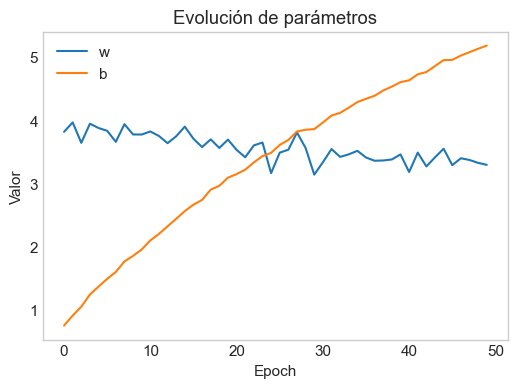

In [25]:
# Ejecuta SGD y visualiza resultados

# resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:
# 1. Datos + linea aprendida por SGD vs linea real
# 2. Curva de loss por epoch
# 3. Evolucion de w y b por epoch
resultado_sgd = sgd_regresion_lineal(
    X_sgd, 
    y_sgd, 
    learning_rate=0.01, 
    epochs=50, 
    batch_size=32
)

w = resultado_sgd['w_final']
b = resultado_sgd['b_final']
loss_hist = resultado_sgd['historial_loss']
hist_w = resultado_sgd['historial_w']
hist_b = resultado_sgd['historial_b']
#Linea Aprendida
plt.figure(figsize=(6,4))
plt.scatter(X_sgd, y_sgd, alpha=0.5, label='Datos')
x_line = np.linspace(0, 10, 100)
y_pred = w * x_line + b
plt.plot(x_line, y_pred, label='SGD')
y_real = 3 * x_line + 7
plt.plot(x_line, y_real, linestyle='--', label='Real')
plt.title("Regresión lineal: SGD vs Real")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()
#Curva de loss
plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.title("Evolución del Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()
#Evolucion de w y b 
plt.figure(figsize=(6,4))
plt.plot(hist_w, label='w')
plt.plot(hist_b, label='b')
plt.title("Evolución de parámetros")
plt.xlabel("Epoch")
plt.ylabel("Valor")
plt.legend()
plt.grid()
plt.show()


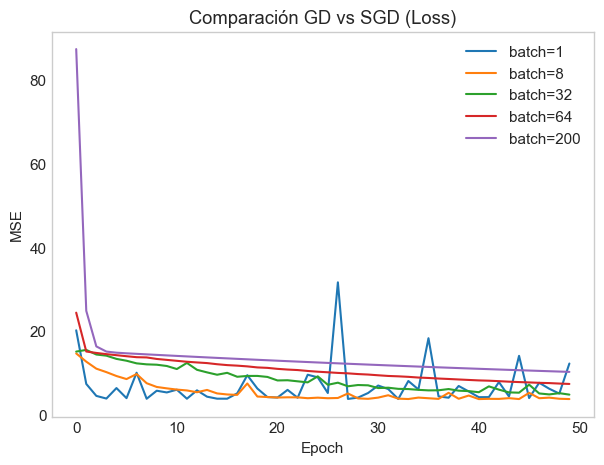

COMPARACIÓN DE PARÁMETROS
Batch         w_final    b_final
1              3.4456     7.5590
8              2.9476     7.3775
32             3.3214     5.2832
64             3.5152     3.5526
200            3.7352     2.3004


In [26]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

# batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

# TU CODIGO: ejecuta para cada batch_size y compara convergencia

batch_sizes = [1, 8, 32, 64, len(X_sgd)]
resultados_batch = {}
for bs in batch_sizes:
    res = sgd_regresion_lineal(
        X_sgd,
        y_sgd,
        learning_rate=0.01,
        epochs=50,
        batch_size=bs
    )
    resultados_batch[bs] = res
    
plt.figure(figsize=(7,5))

for bs, res in resultados_batch.items():
    plt.plot(res['historial_loss'], label=f'batch={bs}')
plt.title("Comparación GD vs SGD (Loss)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

print("COMPARACIÓN DE PARÁMETROS")
print("=" * 60)
print(f"{'Batch':<10} {'w_final':>10} {'b_final':>10}")

for bs, res in resultados_batch.items():
    print(f"{bs:<10} {res['w_final']:>10.4f} {res['b_final']:>10.4f}")

**Preguntas Bonus:**

1. **¿Qué diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *La principal difererncia que hay es que el GD utiliza todos los datos en cada iteracion, lo que produce una convergencia mas estable y suave, pero con mayor costo computacional. En cambio el SGD utiliza una sola muestra, lo que hace mas rapido por iteracion, pero lo malo que introduce ruido en la trayectoria, haciendo que la convergencia sea mas inestable.*

2. **¿Qué batch_size te dio los mejores resultados? ¿Por qué?**
   - *Yo creo que los mejores resultados se obtienen de los batch intermedios, como 8 o 32, ya que estos valores logran un balance entre la estabilidad y eficiencia, reduciendo el ruido presente en SGD, pero sin el alto costo computacional del GD.*

3. **¿Por qué la curva de loss de SGD es más ruidosa que la de GD?**
   - *La curva de loss en SGD es mas ruidosa porque los gradientes se calculan utilizando una sola muestra pequeña de datos, lo que introduce variabilidad a cada iteracion, esto provoca que existan fluctuaciones en el valor del error, sin embargo, GD utiliza todos los datos, generando un gradiente mas preciso y una curva de perdida mas suave.*

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_